In [1]:
import sys
import numpy as np
import torch 
# still do preprocessing in scipy
import scipy.sparse as sp
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from importlib import reload

# import factor model from beta-dirichlet-factor
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/beta-dirichlet-factor')
import factor_model
reload(factor_model)

<module 'factor_model' from '/gpfs/commons/home/kisaev/Leaflet-private/src/beta-dirichlet-factor/factor_model.py'>

In [2]:
leaflet_repo = '/gpfs/commons/home/kisaev/Leaflet-private/src/beta-binomial-mix/'
sys.path.append(leaflet_repo)
import load_cluster_data
from betabinomo_mix_singlecells import *

### Settings and Load data

In [3]:
torch.manual_seed(42)

# set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

float_type = { 
    "device" : device, 
    "dtype" : torch.float, # save memory
}

cuda


In [4]:
input_files_folder = '/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/MLCB_Brain_true/FULL/'

cell_types = ['Brain_Non-Myeloid_brain_pericyte','Brain_Non-Myeloid_oligodendrocyte_precursor_cell','Brain_Non-Myeloid_endothelial_cell','Brain_Non-Myeloid_oligodendrocyte',
 'Brain_Non-Myeloid_neuron', 'Brain_Myeloid_macrophage',
 'Brain_Myeloid_microglial_cell', 'Brain_Non-Myeloid_astrocyte']

#ignoring Bergmann_glial_cell since very few cells

# convert data to Leaflet required input formats 
final_data, coo_counts_sparse, coo_cluster_sparse, cell_ids_conversion, junction_ids_conversion = load_cluster_data.load_cluster_data(
    input_folder = input_files_folder, max_intron_count=5000, celltypes=cell_types, has_genes="yes") 

# add cluster to final_data 
final_data = final_data.merge(junction_ids_conversion, on=["junction_id_index"], how="left")

# get indices (maybe don't need this actually)
indices = (final_data.cell_id_index, final_data.junction_id_index)
indices_np = np.stack(indices)
junc_counts = sp.coo_matrix((final_data.junc_count, indices))
cluster_counts = sp.coo_matrix((final_data.cluster_count, indices))

Reading in data from folder ...
/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/MLCB_Brain_true/FULL/
Finished reading in data from folder ...
Looking at only specific cell types ...['Brain_Non-Myeloid_brain_pericyte', 'Brain_Non-Myeloid_oligodendrocyte_precursor_cell', 'Brain_Non-Myeloid_endothelial_cell', 'Brain_Non-Myeloid_oligodendrocyte', 'Brain_Non-Myeloid_neuron', 'Brain_Myeloid_macrophage', 'Brain_Myeloid_microglial_cell', 'Brain_Non-Myeloid_astrocyte']
['Brain_Non-Myeloid_brain_pericyte'
 'Brain_Non-Myeloid_oligodendrocyte_precursor_cell'
 'Brain_Non-Myeloid_endothelial_cell' 'Brain_Non-Myeloid_oligodendrocyte'
 'Brain_Non-Myeloid_neuron' 'Brain_Myeloid_macrophage'
 'Brain_Myeloid_microglial_cell' 'Brain_Non-Myeloid_astrocyte']
7816
16190
The maximum junction count was initially:  150346
80
The maximum junction count is now:  4982
                                             cell_id  Cluster  Cluster_Counts  \
0  A14-MAA000581-3_10_M-1-1_Brain_Non-M

In [5]:
cell_index_tensor, junc_index_tensor, my_data = make_torch_data(final_data, **float_type)

The number of cells going into training data is:
7816
7816


/gpfs/commons/home/kisaev/Leaflet-private/src/beta-binomial-mix/betabinomo_mix_singlecells.py:333: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at ../aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  ycount_lookup = torch.sparse_coo_tensor(


In [6]:
simple_data = final_data[["cell_id_index", "Cluster", "cell_type", "junction_id_index", "juncratio", "junc_count", "cluster_count",  "junction_id", "gene_id"]]

### Get ready for model training 

In [7]:
if device == torch.device('cuda'):
    torch.set_default_tensor_type('torch.cuda.FloatTensor')

In [8]:
indices = torch.tensor(final_data[['cell_id_index', 'junction_id_index']].to_numpy().T, dtype=torch.long)
values = torch.tensor(final_data['junc_count'].to_numpy(), dtype=torch.float)
# Determine the size of the tensor
num_cells = final_data['cell_id_index'].max() + 1
num_junctions = final_data['junction_id_index'].max() + 1
size = (num_cells, num_junctions)
# Create a sparse tensor
y_tensor = torch.sparse_coo_tensor(indices, values, size)

In [9]:
indices_counts = torch.tensor(final_data[['cell_id_index', 'junction_id_index']].to_numpy().T, dtype=torch.long)
values_counts = torch.tensor(final_data['cluster_count'].to_numpy(), dtype=torch.float)
# Determine the size of the tensor
num_cells_counts = final_data['cell_id_index'].max() + 1
num_junctions_counts = final_data['junction_id_index'].max() + 1
size_counts = (num_cells_counts, num_junctions_counts)
# Create a sparse tensor
total_counts_tensor = torch.sparse_coo_tensor(indices_counts, values_counts, size_counts)

### Run factor model!

In [10]:
import pyro 
import pyro.distributions as dist

N  = num_cells 
P = num_junctions
K = 100 

a = pyro.sample("a", dist.Gamma(1., 1.).expand([P]).to_event(1))
b = pyro.sample("b", dist.Gamma(1., 1.).expand([P]).to_event(1))# per junction to model average behaviour
# in this setup,the behavior of each junction is modeled independently of others
psi_dist = dist.Beta(a, b).expand([K, P]).to_event(2) 
psi = pyro.sample("psi", psi_dist) # shape is K,P
print(psi.shape)

torch.Size([100, 15929])


In [11]:
# import reload 
reload(factor_model)

<module 'factor_model' from '/gpfs/commons/home/kisaev/Leaflet-private/src/beta-dirichlet-factor/factor_model.py'>

Not using global prior for psi, junctions are independent across factors
Initialization 1 with seed 2973
Define the guide
Fit the model
Epoch 0, Loss: 215161910.13180256
Epoch 10, Loss: 122301895.93669254
Epoch 20, Loss: 86503527.47016358
Epoch 30, Loss: 72912455.48204637
Epoch 40, Loss: 67354259.3458643
Epoch 50, Loss: 64540844.97549772
Epoch 60, Loss: 62900776.438480616
Epoch 70, Loss: 61847020.772969365
Epoch 80, Loss: 61110647.79591107
Epoch 90, Loss: 60563712.12423861
Epoch 100, Loss: 60141756.58896649
Epoch 110, Loss: 59785890.442349195
Epoch 120, Loss: 59502120.3370316
Epoch 130, Loss: 59258437.231426835
Epoch 140, Loss: 59060438.05064356
Epoch 150, Loss: 58874102.390265465
Epoch 160, Loss: 58727098.869231224
Epoch 170, Loss: 58588449.79654193
Epoch 180, Loss: 58475968.354034424
Epoch 190, Loss: 58366387.601940274


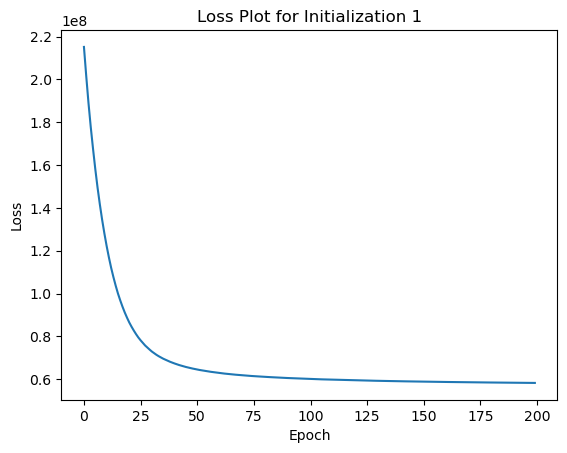

Sample from the guide (posterior)
Extract the latent variables
Initialization 2 with seed 5677
Define the guide
Fit the model
Epoch 0, Loss: 215687445.616889
Epoch 10, Loss: 122534021.9120134
Epoch 20, Loss: 86682345.7719686
Epoch 30, Loss: 72973077.39035523
Epoch 40, Loss: 67174997.32244897
Epoch 50, Loss: 64146613.02971625
Epoch 60, Loss: 62424278.49629331
Epoch 70, Loss: 61362571.49016464
Epoch 80, Loss: 60640681.67445409
Epoch 90, Loss: 60087428.88530028
Epoch 100, Loss: 59655418.893042564
Epoch 110, Loss: 59314545.27262795
Epoch 120, Loss: 59022790.81500006
Epoch 130, Loss: 58784974.42055452
Epoch 140, Loss: 58580366.97328007
Epoch 150, Loss: 58404116.798680305
Epoch 160, Loss: 58255697.50108278
Epoch 170, Loss: 58123952.68648696
Epoch 180, Loss: 58000708.79062343
Epoch 190, Loss: 57894870.82414758


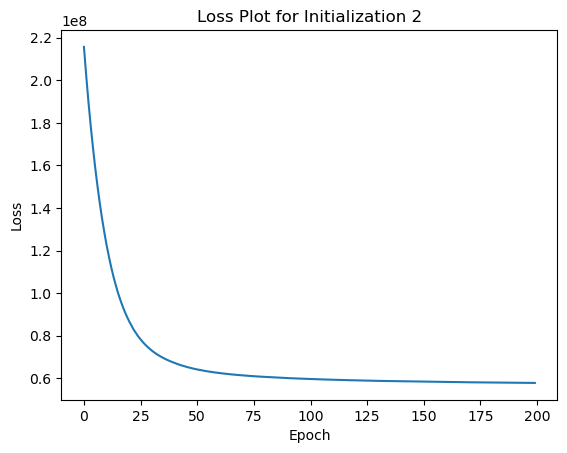

Sample from the guide (posterior)
Extract the latent variables
All initializations complete. Returning results.
------------------------------------------------


In [12]:
K = 20
all_results = factor_model.main(y_tensor, total_counts_tensor, num_initializations=2, use_global_prior=False, K=K, lr=0.1, loss_plot=True, num_epochs=200, save_to_file = False)

In [13]:
latent_vars = all_results[0]['latent_vars'] # latent variables for just first seed

In [14]:
latent_vars

{'_AutoDiagonalNormal_latent': array([-2.5837107 ,  1.1786795 , -0.88153285, ..., -0.06074274,
        -9.891287  , -0.90808606], dtype=float32),
 'data2': array([   0,    1,    2, ..., 7813, 7814, 7815]),
 'psi': array([[0.07019416, 0.7647103 , 0.29286024, ..., 0.00244571, 0.8632833 ,
         0.01974091],
        [0.01400537, 0.93649393, 0.5277663 , ..., 0.01046109, 0.9915081 ,
         0.13991039],
        [0.47220528, 0.5390697 , 0.9968664 , ..., 0.08174036, 0.8218223 ,
         0.45586836],
        ...,
        [0.420653  , 0.50106   , 0.16539179, ..., 0.05280522, 0.2757664 ,
         0.44083032],
        [0.3893897 , 0.43921226, 0.82761127, ..., 0.5209488 , 0.4736734 ,
         0.9795221 ],
        [0.6341608 , 0.8179375 , 0.24029736, ..., 0.046382  , 0.9373645 ,
         0.86230624]], dtype=float32),
 'pi': array([0.07216994, 0.05694529, 0.05750458, 0.04186006, 0.13356173,
        0.04429582, 0.05331729, 0.12535134, 0.05381371, 0.05187358,
        0.04451912, 0.05518212, 0.04545

In [15]:
# extract latent variables
pi = latent_vars["pi"] # overall contribution of each factor to cell population
conc = latent_vars["conc"] # one scaling value 

assign_post = latent_vars["assign"]

psis = latent_vars["psi"] # psi is the probability of a junction being used in a cluster

global_prior = False 
if global_prior:
    a = latent_vars["a"] # a is the alpha parameter of the beta distribution (if no global prior used, then this is one value per junction)
    b = latent_vars["b"] # b is the beta parameter of the beta distribution (if no global prior used, then this is one value per junction)
    print(a.shape)
    print(b.shape)

In [16]:
print("The inferred concentration parameter is: " + str(conc))
print("The inferred pi parameter is: " + str(pi))

The inferred concentration parameter is: 3.9059968
The inferred pi parameter is: [0.07216994 0.05694529 0.05750458 0.04186006 0.13356173 0.04429582
 0.05331729 0.12535134 0.05381371 0.05187358 0.04451912 0.05518212
 0.04545306 0.03186152 0.03196226 0.02547123 0.02109166 0.01860034
 0.01854467 0.01662078]


### Evaluate latent variables 

In [17]:
color_palette = sns.color_palette("Set1", n_colors=len(cell_ids_conversion['cell_type'].unique()))
# Create a color bar legend
legend = sns.color_palette(palette=color_palette, as_cmap=True)

# Obtain cell type labels for every cell in the matrix also 
unique_cell_types = cell_ids_conversion['cell_type'].unique()
num_unique_types = len(unique_cell_types)
colors = sns.color_palette('Set1', n_colors=num_unique_types)  # You can use any color palette
cell_types = cell_ids_conversion.cell_type.values

# create colours for each cell type 
cell_type_colors = {cell_type: color for cell_type, color in zip(unique_cell_types, colors)}
row_colors = [cell_type_colors[cell_type] for cell_type in cell_types]

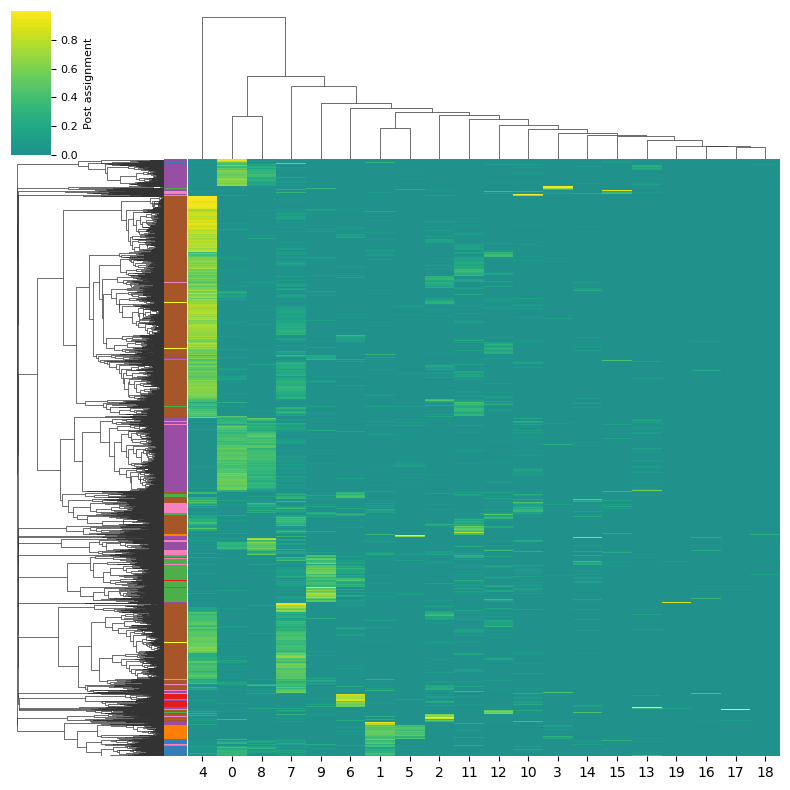

In [18]:
cluster = sns.clustermap(
    data=assign_post,
    method='complete',
    cmap="viridis",
    annot=False,
    fmt=".2f",
    yticklabels=False,
    figsize=(8, 8),
    center=0,
    row_colors=row_colors,  # Apply row colors
    cbar_kws={'label': 'Post assignment'} 
    )
cluster.cax.set_ylabel('Post assignment', size=8)
# Increase font size for color bar tick labels:
cbar_ax = cluster.cax
for label in cbar_ax.yaxis.get_ticklabels():
    label.set_size(8)

Text(0.5, 0, 'Cell Type')

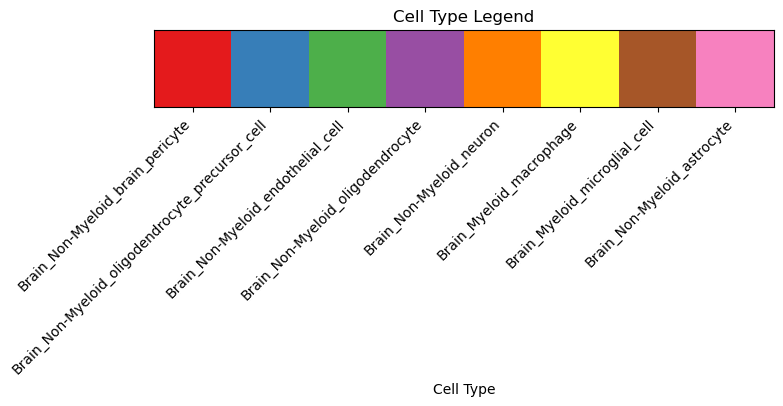

In [19]:
# print cell type color legend seperately
cell_type_colors
# Create a color bar legend
legend = sns.color_palette(palette=color_palette, as_cmap=True)
sns.palplot(color_palette)
plt.title("Cell Type Legend")
# add cell type names to legend
plt.xticks(np.arange(len(unique_cell_types)), unique_cell_types, rotation=45, ha='right')
plt.xlabel("Cell Type")


In [20]:
# let's calculate silhouette score ussing assign_post
ss = silhouette_score(assign_post, cell_types)
# print with K equals K the ss is 
print("The silhouette score for K = " + str(K) + " is: " + str(ss))

The silhouette score for K = 20 is: 0.088483475


In [21]:
# get davies bouldin score
from sklearn.metrics import davies_bouldin_score
dbs = davies_bouldin_score(assign_post, cell_types)
print("The Davies Bouldin score for K = " + str(K) + " is: " + str(dbs))

The Davies Bouldin score for K = 20 is: 2.0760595368620827


## Evaluate performance on imputation/masking task

In [22]:
# import factor model from beta-dirichlet-factor
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/evaluations')
import masking
from masking import *

In [23]:
# import reload 
from importlib import reload
reload(masking)

<module 'masking' from '/gpfs/commons/home/kisaev/Leaflet-private/src/evaluations/masking.py'>

In [82]:
#1. get masked matrix using intron cluster counts for this mouse brain data 
masking_percs = [0.1, 0.2, 0.3, 0.4, 0.5]
masks_list = []

# get masked matrix for each masking percentage
for perc_mask in masking_percs:
    print("The masking percentage is: " + str(perc_mask))
    masked_matrix = generate_mask(cluster_counts, mask_percentage = perc_mask)
    masks_list.append(masked_matrix)

The masking percentage is: 0.1


Number of entries (junction-cell pairs) masked:  1054635.0
The masking percentage is: 0.2
Number of entries (junction-cell pairs) masked:  2109270.0
The masking percentage is: 0.3
Number of entries (junction-cell pairs) masked:  3163906.0
The masking percentage is: 0.4
Number of entries (junction-cell pairs) masked:  4218541.0
The masking percentage is: 0.5
Number of entries (junction-cell pairs) masked:  5273177.0


In [86]:
#2. get junction and intron cluster count matrices with masked values 
masked_counts = []

for i in range(len(masking_percs)):
    print("The masking percentage is: " + str(masking_percs[i]))
    masked_junction_counts, masked_intron_clusts = apply_mask(junc_counts, cluster_counts, masks_list[i])
    # appent masked junction and intron cluster counts to list
    masked_counts.append((masked_junction_counts, masked_intron_clusts))

The masking percentage is: 0.1


The masking percentage is: 0.2
The masking percentage is: 0.3
The masking percentage is: 0.4
The masking percentage is: 0.5


In [87]:
#3. get input files for factor model (junction and intron cluster sparse tensor)
model_input_files = [] 

for i in range(len(masking_percs)):
    print("The masking percentage is: " + str(masking_percs[i]))
    masked_junction_counts, masked_intron_clusts = masked_counts[i]
    # get y_tensor and total_counts_tensor via prep_model_input function
    y_tensor, total_counts_tensor = prep_model_input(masked_junction_counts, masked_intron_clusts)
    # append to model_input_files list
    model_input_files.append((y_tensor, total_counts_tensor))

The masking percentage is: 0.1


The masking percentage is: 0.2
The masking percentage is: 0.3
The masking percentage is: 0.4
The masking percentage is: 0.5


In [90]:
# Now can run factor model on masked data
Ks = [2, 5, 8, 20, 50, 100]
all_Ks_results = {}

for k in Ks:
    
    print("------------------------------------------------")
    print("Running factor model for K = " + str(k))
    print("------------------------------------------------")
    
    # now also iterate over masking percentages 
    for i in range(len(masking_percs)):
        print("The masking percentage is: " + str(masking_percs[i]))
        y_tensor, total_counts_tensor = model_input_files[i]
        # run factor model
        masked_results = factor_model.main(y_tensor, total_counts_tensor, num_initializations=3, use_global_prior=False, K=k, lr=0.1, loss_plot=False, num_epochs=100, save_to_file = False)
        # save results to dictionary
        all_Ks_results[(k, masking_percs[i])] = masked_results

------------------------------------------------
Running factor model for K = 2
------------------------------------------------
The masking percentage is: 0.1
Not using global prior for psi, junctions are independent across factors
Initialization 1 with seed 2393
Define the guide
Fit the model
Epoch 0, Loss: 198523208.91874778


Epoch 10, Loss: 111968800.24079406
Epoch 20, Loss: 80352690.66401327
Epoch 30, Loss: 69549814.87316704
Epoch 40, Loss: 65537986.35141206
Epoch 50, Loss: 63480851.4014132
Epoch 60, Loss: 62115856.05633056
Epoch 70, Loss: 61180982.065876365
Epoch 80, Loss: 60520432.715167224
Epoch 90, Loss: 60093182.87171161
Sample from the guide (posterior)
Extract the latent variables
Initialization 2 with seed 5997
Define the guide
Fit the model
Epoch 0, Loss: 198271482.72251052
Epoch 10, Loss: 111893793.70797808
Epoch 20, Loss: 80368527.95779526
Epoch 30, Loss: 69372420.70263731
Epoch 40, Loss: 64929487.47867048
Epoch 50, Loss: 62624789.80187982
Epoch 60, Loss: 61359139.01700419
Epoch 70, Loss: 60609362.83007455
Epoch 80, Loss: 60135329.42767608
Epoch 90, Loss: 59833359.859298274
Sample from the guide (posterior)
Extract the latent variables
Initialization 3 with seed 5014
Define the guide
Fit the model
Epoch 0, Loss: 198011346.126799
Epoch 10, Loss: 111167596.53916618
Epoch 20, Loss: 80292246.039358

In [94]:
# get pearson correlation and l1 error between true and inferred parameters (PSI)
masked_perf = []

Ks = [2, 5, 8, 20, 50, 100]
masked_percs = [0.1, 0.2, 0.3, 0.4, 0.5]

for k in Ks:
    for perc_mask in masking_percs:
        print("Calculating performance for K = " + str(k) + " and masking percentage = " + str(perc_mask))
        masked_results = all_Ks_results[(k, perc_mask)]        
        for res in masked_results:
            # get seed that was used 
            seed = res['seed']

            # get latent variables
            psi = res['latent_vars']["psi"] # psi is the probability of a junction being used in a cluster
            assign_post=res['latent_vars']["assign"]

            # get K 
            K = psi.shape[0]
            J = psi.shape[1]

            # get scores 
            l1, r = evaluate_model(junc_counts.toarray(), cluster_counts.toarray(), psi, assign_post, masks)

            # get num epochs trained for 
            nepoch = len(res["losses"])

            # save to list 
            masked_perf.append([seed, l1, r, K, perc_mask, J, nepoch])

Calculating performance for K = 2 and masking percentage = 0.1


/gpfs/commons/home/kisaev/Leaflet-private/src/evaluations/masking.py:177: RuntimeWarning: invalid value encountered in divide
  true_psi = true_juncs / true_clusts


L1 error:  0.16996816171738827
Pearson correlation:  0.7298324893519236
L1 error:  0.1691838784708332
Pearson correlation:  0.7307760523214035


In [30]:
# make masked_perf a dataframe 
masked_perf_df = pd.DataFrame(masked_perf, columns=["seed", "l1", "r", "K", "J", "num_epochs"])

In [31]:
masked_perf_df

,seed,l1,r,K,J,num_epochs
0,5810,0.169427,0.729780,2,15929,100
1,8317,0.169118,0.730909,2,15929,100
2,5482,0.165297,0.737260,5,15929,100
3,7678,0.167443,0.734335,5,15929,100
4,6392,0.164273,0.739869,8,15929,100
5,2268,0.165283,0.737840,8,15929,100
6,2774,0.164230,0.738553,20,15929,100
7,4372,0.164215,0.739197,20,15929,100
8,7535,0.164991,0.736797,50,15929,100
9,1273,0.165444,0.735853,50,15929,100


0.16421545139541918


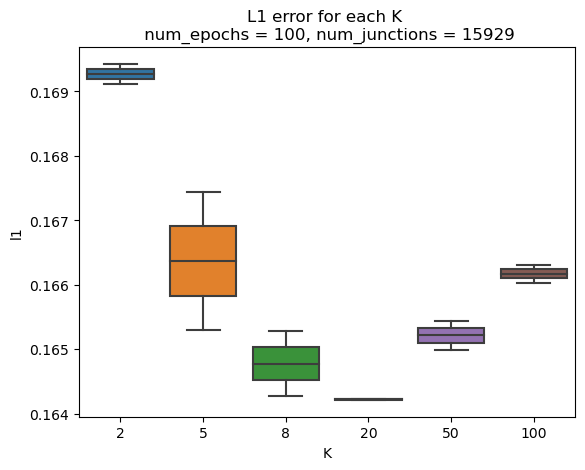

In [32]:
# make boxplot of l1 error for each K
sns.boxplot(data=masked_perf_df, x="K", y="l1")
# add title to show number of junctions and num_epochs 
num_epochs = masked_perf_df.num_epochs.unique()[0]
num_junctions = masked_perf_df.J.unique()[0]
plt.title("L1 error for each K \n num_epochs = " + str(num_epochs) + ", num_junctions = " + str(num_junctions))
print(masked_perf_df.l1.min())

0.7398686454269958


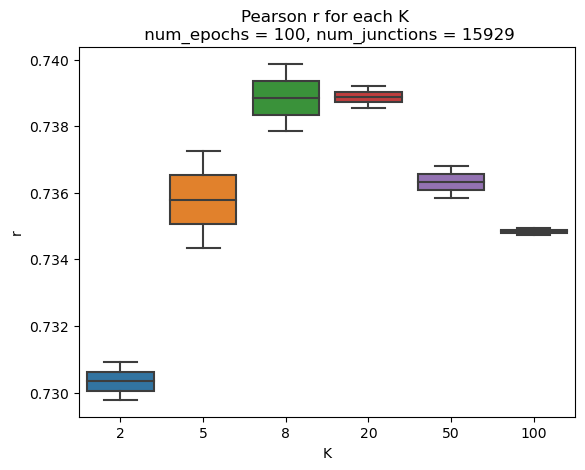

In [33]:
# make boxplot of pearson correlation for each K
sns.boxplot(data=masked_perf_df, x="K", y="r")
# add title to show number of junctions and num_epochs 
num_epochs = masked_perf_df.num_epochs.unique()[0]
num_junctions = masked_perf_df.J.unique()[0]
plt.title("Pearson r for each K \n num_epochs = " + str(num_epochs) + ", num_junctions = " + str(num_junctions))
print(masked_perf_df.r.max())

## Try now with global priors on a and b 

In [34]:
# Now can run factor model on masked data
all_Ks_results_prior = {}
for k in Ks:
    print("------------------------------------------------")
    print("Running factor model for K = " + str(k))
    print("------------------------------------------------")
    all_Ks_results_prior[k] = factor_model.main(y_tensor, total_counts_tensor, num_initializations=2, file_prefix = "with_prior", use_global_prior=True, K=k, lr=0.1, loss_plot=False, num_epochs=100, save_to_file=False)
    print("Done running factor model for K = " + str(k))

-----------------------------------------
Running factor model for K = 2
Using global prior for psi, junctions are shared across factors
Initialization 1 with seed 9899
Define the guide
Fit the model
Epoch 0, Loss: 241258025.29722828
Epoch 10, Loss: 138084115.97391325
Epoch 20, Loss: 93560477.43840444
Epoch 30, Loss: 75712272.68405282
Epoch 40, Loss: 68357851.56815398
Epoch 50, Loss: 65086316.66964948
Epoch 60, Loss: 63376040.855609655
Epoch 70, Loss: 62259060.727582455
Epoch 80, Loss: 61488296.653989136
Epoch 90, Loss: 60913073.92210674
Sample from the guide (posterior)
Extract the latent variables
Initialization 2 with seed 7670
Define the guide
Fit the model
Epoch 0, Loss: 243559779.80564892
Epoch 10, Loss: 140099422.39158362
Epoch 20, Loss: 94995546.7263034
Epoch 30, Loss: 77112745.92680067
Epoch 40, Loss: 69587051.47233719
Epoch 50, Loss: 66281986.21236062
Epoch 60, Loss: 64468599.762506604
Epoch 70, Loss: 63168583.1560477
Epoch 80, Loss: 62069047.97647524
Epoch 90, Loss: 61224611

In [37]:
Ks

[2, 5, 8, 20, 50, 100]

In [38]:
# get pearson correlation and l1 error between true and inferred parameters (PSI)

masked_perf_prior = []

for k in Ks:
    print("Calculating performance for K = " + str(k))
    print("-----------------------------------------")
    masked_results = all_Ks_results_prior[k]
    for res in masked_results:
        
        # get seed that was used 
        seed = res['seed']
        
        # get latent variables
        psi = res['latent_vars']["psi"] # psi is the probability of a junction being used in a cluster
        assign_post=res['latent_vars']["assign"]

        # get K 
        K = psi.shape[0]
        J = psi.shape[1]

        # get scores 
        l1, r = evaluate_model(junc_counts.toarray(), cluster_counts.toarray(), psi, assign_post, masks)

        # get num epochs trained for 
        nepoch = len(res["losses"])

        # save to list 
        masked_perf_prior.append([seed, l1, r, K, J, nepoch])

Calculating performance for K = 2
-----------------------------------------


/gpfs/commons/home/kisaev/Leaflet-private/src/evaluations/masking.py:177: RuntimeWarning: invalid value encountered in divide
  true_psi = true_juncs / true_clusts


L1 error:  0.17087605291424734
Pearson correlation:  0.7282616803246552
L1 error:  0.1712071449296431
Pearson correlation:  0.7269433634140804
Calculating performance for K = 5
-----------------------------------------
L1 error:  0.16709768018801807
Pearson correlation:  0.7351199614043392
L1 error:  0.1661905889378987
Pearson correlation:  0.7363429277251013
Calculating performance for K = 8
-----------------------------------------
L1 error:  0.16488132293468594
Pearson correlation:  0.7392556443388122
L1 error:  0.1656537471814201
Pearson correlation:  0.7384455860840906
Calculating performance for K = 20
-----------------------------------------
L1 error:  0.16465477984941795
Pearson correlation:  0.7384590758696138
L1 error:  0.1652200008432514
Pearson correlation:  0.7378371186543199
Calculating performance for K = 50
-----------------------------------------
L1 error:  0.16482526066306208
Pearson correlation:  0.7373494685317487
L1 error:  0.16544168763866612
Pearson correlation

In [39]:
# make masked_perf a dataframe 
masked_perf_df = pd.DataFrame(masked_perf_prior, columns=["seed", "l1", "r", "K", "J", "num_epochs"])

0.16465477984941795


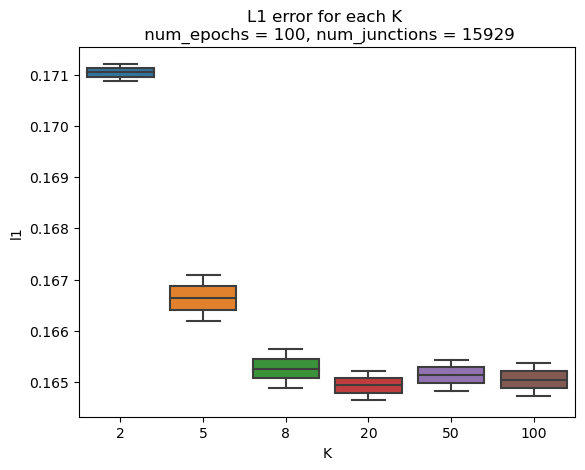

In [40]:
# make boxplot of l1 error for each K
sns.boxplot(data=masked_perf_df, x="K", y="l1")
# add title to show number of junctions and num_epochs 
num_epochs = masked_perf_df.num_epochs.unique()[0]
num_junctions = masked_perf_df.J.unique()[0]
plt.title("L1 error for each K \n num_epochs = " + str(num_epochs) + ", num_junctions = " + str(num_junctions))
print(masked_perf_df.l1.min())

0.7392556443388122


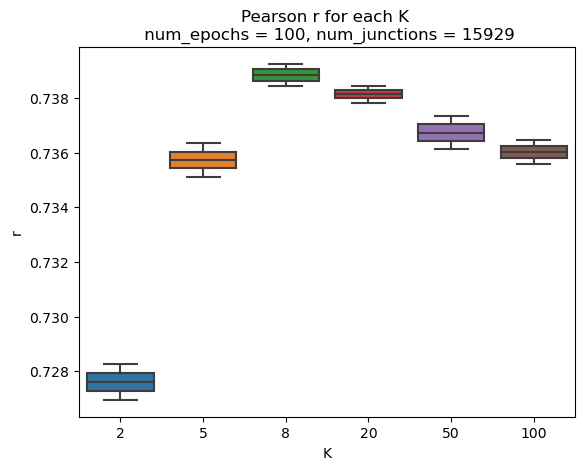

In [41]:
# make boxplot of pearson correlation for each K
sns.boxplot(data=masked_perf_df, x="K", y="r")
# add title to show number of junctions and num_epochs 
num_epochs = masked_perf_df.num_epochs.unique()[0]
num_junctions = masked_perf_df.J.unique()[0]
plt.title("Pearson r for each K \n num_epochs = " + str(num_epochs) + ", num_junctions = " + str(num_junctions))
print(masked_perf_df.r.max())

In [42]:
all_Ks_results_prior[100][0]["latent_vars"]["psi"]

array([[0.5455459 , 0.58391505, 0.32696757, ..., 0.07965006, 0.78308797,
        0.7789618 ],
       [0.09861884, 0.6586314 , 0.3141384 , ..., 0.03683001, 0.36059794,
        0.29566723],
       [0.23424925, 0.1339925 , 0.05559696, ..., 0.03561222, 0.80627775,
        0.9102396 ],
       ...,
       [0.02018055, 0.28554988, 0.6604762 , ..., 0.06614498, 0.26682815,
        0.3251026 ],
       [0.60862863, 0.07359456, 0.821424  , ..., 0.09393826, 0.568526  ,
        0.5412969 ],
       [0.12943193, 0.43615225, 0.7702865 , ..., 0.2029125 , 0.34607303,
        0.69415665]], dtype=float32)

In [43]:
a = all_Ks_results_prior[100][0]["latent_vars"]["a"]
b = all_Ks_results_prior[100][0]["latent_vars"]["b"]

In [44]:
mu = a/(a+b)
s = a+b

print(mu)
print(s)

[0.45426366 0.53062236 0.59866166 ... 0.09087526 0.51139754 0.4536202 ]
[2.3683605 2.7545557 1.8676927 ... 9.185857  3.7412715 2.6927662]


0.6474003
0.6548813


<Axes: ylabel='Density'>

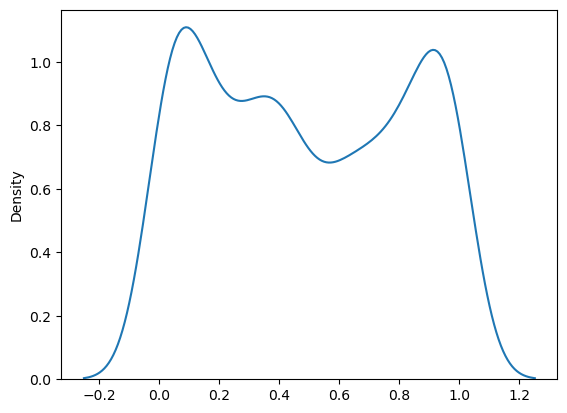

In [76]:
# sample i 

i = np.random.randint(0, J)
print(a[i])
print(b[i])

sns.kdeplot(np.random.beta(a[i], b[i], 1000), label="Factor " + str(i))

/gpfs/commons/home/kisaev/.local/lib/python3.9/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<Axes: ylabel='Density'>

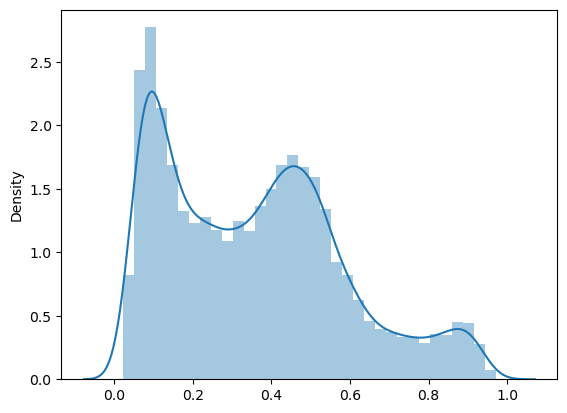

In [79]:
mus = a/(a+b)
ss = a+b

# print histogram of mus
sns.distplot(mus, kde=True)

/gpfs/commons/home/kisaev/.local/lib/python3.9/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<Axes: xlabel='juncratio', ylabel='Density'>

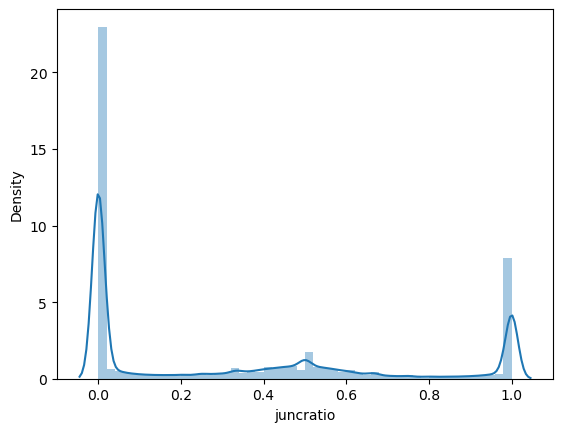

In [81]:
# print plot of true psis 
sns.distplot(final_data.juncratio, kde=True)